# Multi-Model Detection Evaluation — Faster R-CNN vs RF-DETR vs YOLOv8

Evaluates all three detectors on the **same** test split in one pass and saves
the per-model diagnostic plots, then produces the row-normalised confusion-matrix
comparison figure used in the report.

## What this notebook does
1. **Predictions** — for each model, loads its weights from `../model_showcase/`
   and runs inference on the test split, caching the COCO-results JSON to that
   model's `runs/.../predictions_test.json` (skipped if the cache already exists).
2. **Per-model plots** — confusion matrix, threshold sweep, object-size
   distribution, spatial error grid, wrong-class crops, FP/FN crops — saved into
   each model's `runs/` folder (same outputs as the single-model `evaluation.ipynb`).
3. **Report figure** — a single side-by-side panel of the **row-normalised**
   confusion matrices for all three models, saved to `../report/images/`.

Each model is matched at its own best confidence threshold
(Faster R-CNN 0.7, RF-DETR 0.4, YOLOv8 0.3) at IoU > 0.5.

## 1. Setup & configuration

In [13]:
from pathlib import Path
import json
import random
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from tqdm.auto import tqdm
import supervision as sv

# ── Shared dataset config (paths relative to this notebook in 3_Model/) ───────
GT_ANNOTATIONS = Path("../Data/lars_processed/test/_annotations.coco.json")
IMAGES_DIR     = Path("../Data/lars_processed/test/images")

# Generated report figures go here; per-model plots go to each model's runs dir
REPORT_IMG_DIR = Path("../report/images").resolve()
REPORT_IMG_DIR.mkdir(parents=True, exist_ok=True)

IOU_THRESH = 0.5            # IoU threshold for TP/FP matching
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility (project convention: seed 4)
random.seed(4); np.random.seed(4); torch.manual_seed(4)

# ── The three models to compare ──────────────────────────────────────────────
# Each entry carries everything needed to (a) run inference and (b) match at the
# model's own operating threshold. save_dir mirrors the runs/ layout so the
# per-model plots land next to that model's other artefacts.
MODELS = [
    {
        "key":       "fasterrcnn",
        "label":     "Faster R-CNN",
        "family":    "fasterrcnn",
        "weights":   Path("../model_showcase/fasterrcnn_trial002.pth"),
        "threshold": 0.7,                       # best-F1 operating point
        "save_dir":  Path("../runs/fasterrcnn/optuna/trial_002"),
    },
    {
        "key":        "rfdetr",
        "label":      "RF-DETR",
        "family":     "rfdetr",
        "weights":    Path("../model_showcase/rfdetr_trial004.pth"),
        "threshold":  0.4,
        "resolution": 784,                      # trial_004 was trained at 784
        "save_dir":   Path("../runs/rfdetr/optuna_relabeled_lb/trial_004"),
    },
    {
        "key":       "yolo",
        "label":     "YOLOv8",
        "family":    "yolo",
        "weights":   Path("../model_showcase/yolo_exp7.pt"),
        "threshold": 0.3,
        "imgsz":     1024,
        "save_dir":  Path("../runs/yolo/exp7_yolov8m_ep100_img1024_b4"),
    },
]

print(f"Device: {DEVICE}")
print(f"Report figures -> {REPORT_IMG_DIR}")
for m in MODELS:
    print(f"  {m['label']:<14} thr={m['threshold']}  weights={m['weights'].name}")

Device: cuda
Report figures -> /home/ubuntu/workspace/navigation_project/AP2026-Maritime-Navigation/report/images
  Faster R-CNN   thr=0.7  weights=fasterrcnn_trial002.pth
  RF-DETR        thr=0.4  weights=rfdetr_trial004.pth
  YOLOv8         thr=0.3  weights=yolo_exp7.pt


## 2. Load ground truth (shared across all models)

In [14]:
# Ground-truth annotations are identical for every model, so load them once.
ann        = json.load(open(GT_ANNOTATIONS))
img_meta   = {img["id"]: img for img in ann["images"]}
categories = ann["categories"]

CLASS_IDS   = [c["id"]   for c in categories]   # original COCO category IDs
CLASS_NAMES = [c["name"] for c in categories]
id_to_idx   = {cid: i for i, cid in enumerate(CLASS_IDS)}   # COCO id -> 0..N-1
N_CLASSES   = len(CLASS_IDS)

ann_by_img = {}
for a in ann["annotations"]:
    ann_by_img.setdefault(a["image_id"], []).append(a)

# Build the shared list of GT detections (one sv.Detections per image, in a
# fixed image order reused for every model so rows always line up).
IMG_ID_ORDER = list(img_meta.keys())
all_gt_dets  = []
for img_id in IMG_ID_ORDER:
    gt_anns = ann_by_img.get(img_id, [])
    if gt_anns:
        gt_xyxy = np.array([[a["bbox"][0], a["bbox"][1],
                             a["bbox"][0] + a["bbox"][2],
                             a["bbox"][1] + a["bbox"][3]] for a in gt_anns], dtype=float)
        gt_cids = np.array([a["category_id"] for a in gt_anns], dtype=int)
    else:
        gt_xyxy = np.empty((0, 4), dtype=float)
        gt_cids = np.array([], dtype=int)
    all_gt_dets.append(sv.Detections(xyxy=gt_xyxy, class_id=gt_cids))

print(f"Dataset: {len(img_meta)} images, {len(ann['annotations'])} GT annotations")
print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")

Dataset: 503 images, 1605 GT annotations
Classes (8): ['Boat/ship', 'Row boats', 'Paddle board', 'Buoy', 'Swimmer', 'Animal', 'Float', 'Other']


## 3. Matching helpers

In [15]:
# IoU + greedy detection matching, shared by the confusion matrix and the
# threshold sweep. Identical logic to the single-model evaluation.ipynb.

def box_iou(a, b):
    """IoU between two xyxy boxes."""
    xi1, yi1 = max(a[0], b[0]), max(a[1], b[1])
    xi2, yi2 = min(a[2], b[2]), min(a[3], b[3])
    inter    = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    area_a   = (a[2] - a[0]) * (a[3] - a[1])
    area_b   = (b[2] - b[0]) * (b[3] - b[1])
    union    = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_detections(pred_det, gt_det, iou_thresh=0.5):
    """Greedy IoU match (preds sorted by descending confidence).

    Returns (matched, fn_list, fp_list):
      matched : [(gt_class, pred_class, pred_score, pred_box, gt_box), ...]
      fn_list : [(gt_box, gt_class), ...]              unmatched GT
      fp_list : [(pred_box, pred_class, pred_score), ...] unmatched predictions
    """
    pred_boxes   = pred_det.xyxy     if len(pred_det) > 0 else np.empty((0, 4))
    pred_classes = pred_det.class_id if len(pred_det) > 0 else np.array([], dtype=int)
    pred_scores  = (pred_det.confidence
                    if pred_det.confidence is not None and len(pred_det) > 0
                    else np.ones(len(pred_det)))
    gt_boxes     = gt_det.xyxy       if len(gt_det) > 0 else np.empty((0, 4))
    gt_classes   = gt_det.class_id   if len(gt_det) > 0 else np.array([], dtype=int)

    if len(pred_boxes) == 0:
        return [], [(gt_boxes[i], gt_classes[i]) for i in range(len(gt_boxes))], []
    if len(gt_boxes) == 0:
        return [], [], [(pred_boxes[i], pred_classes[i], pred_scores[i])
                        for i in range(len(pred_boxes))]

    order        = np.argsort(-pred_scores)
    pred_boxes   = pred_boxes[order]
    pred_classes = pred_classes[order]
    pred_scores  = pred_scores[order]

    matched_gt, matched_pred = {}, {}
    for pi, pb in enumerate(pred_boxes):
        best_iou, best_gi = iou_thresh, -1
        for gi in range(len(gt_boxes)):
            if gi in matched_gt:
                continue
            iou = box_iou(pb, gt_boxes[gi])
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_gi >= 0:
            matched_gt[best_gi] = pi
            matched_pred[pi]    = best_gi

    matched = [(gt_classes[gi], pred_classes[pi], pred_scores[pi],
                pred_boxes[pi], gt_boxes[gi]) for gi, pi in matched_gt.items()]
    fn_list = [(gt_boxes[i], gt_classes[i])
               for i in range(len(gt_boxes)) if i not in matched_gt]
    fp_list = [(pred_boxes[i], pred_classes[i], pred_scores[i])
               for i in range(len(pred_boxes)) if i not in matched_pred]
    return matched, fn_list, fp_list


def cls_name(cid):
    """Map an original COCO category id to its class name."""
    idx = id_to_idx.get(int(cid), -1)
    return CLASS_NAMES[idx] if 0 <= idx < N_CLASSES else str(cid)

## 4. Generate predictions (inline inference, cached)

For each model, if its `predictions_test.json` is missing we load the weights and
run inference over the whole test split at threshold 0.0 (keep everything — the
evaluation below re-filters per model). Results are cached, so subsequent runs are
instant. The first run is slow: three models over the full test split on GPU.

In [16]:
# Per-family inference adapters. Each returns a COCO-results list:
#   [{"image_id", "category_id", "bbox":[x,y,w,h], "score"}, ...]
# category_id is mapped back to the ORIGINAL COCO ids so it matches the GT.

def _gen_fasterrcnn(cfg):
    """Faster R-CNN: labels are 1-indexed (0 = background) -> map to COCO ids."""
    import torchvision.transforms.functional as TF
    from train_fasterrcnn import build_model

    model = build_model("base", N_CLASSES + 1)          # +1 background class
    model.load_state_dict(torch.load(cfg["weights"], map_location=DEVICE))
    model.to(DEVICE).eval()
    idx_to_cat = {i + 1: c["id"] for i, c in enumerate(categories)}  # 1-idx -> COCO id

    results = []
    with torch.no_grad():
        for img_id, meta in tqdm(img_meta.items(), desc="Faster R-CNN"):
            t   = TF.to_tensor(Image.open(IMAGES_DIR / meta["file_name"]).convert("RGB")).to(DEVICE)
            out = model([t])[0]
            for box, label, score in zip(out["boxes"].cpu().numpy(),
                                         out["labels"].cpu().numpy(),
                                         out["scores"].cpu().numpy()):
                x1, y1, x2, y2 = box.tolist()
                results.append({"image_id": int(img_id),
                                "category_id": int(idx_to_cat.get(int(label), int(label))),
                                "bbox": [x1, y1, x2 - x1, y2 - y1],
                                "score": float(score)})
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return results


def _gen_rfdetr(cfg):
    """RF-DETR: 0-indexed class ids -> map to COCO ids via CLASS_IDS."""
    from rfdetr import RFDETRBase

    model = RFDETRBase(resolution=cfg["resolution"], num_classes=N_CLASSES,
                       pretrain_weights=str(cfg["weights"]))
    results = []
    for img_id, meta in tqdm(img_meta.items(), desc="RF-DETR"):
        pil  = Image.open(IMAGES_DIR / meta["file_name"]).convert("RGB")
        dets = model.predict(pil, threshold=0.0)
        if len(dets) == 0:
            continue
        scores = dets.confidence if dets.confidence is not None else np.ones(len(dets))
        for box, cidx, score in zip(dets.xyxy, dets.class_id, scores):
            x1, y1, x2, y2 = box.tolist()
            cat_id = CLASS_IDS[int(cidx)] if int(cidx) < N_CLASSES else int(cidx)
            results.append({"image_id": int(img_id), "category_id": int(cat_id),
                            "bbox": [x1, y1, x2 - x1, y2 - y1], "score": float(score)})
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return results


def _gen_yolo(cfg):
    """YOLOv8: 0-indexed class ids -> map to COCO ids via CLASS_IDS."""
    from ultralytics import YOLO

    model = YOLO(str(cfg["weights"]))
    results = []
    for img_id, meta in tqdm(img_meta.items(), desc="YOLOv8"):
        res = model.predict(source=str(IMAGES_DIR / meta["file_name"]),
                            imgsz=cfg["imgsz"], conf=0.0, device=DEVICE, verbose=False)[0]
        if res.boxes is None or len(res.boxes) == 0:
            continue
        for box, label, score in zip(res.boxes.xyxy.cpu().numpy(),
                                     res.boxes.cls.cpu().numpy().astype(int),
                                     res.boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = box.tolist()
            cat_id = CLASS_IDS[int(label)] if int(label) < N_CLASSES else int(label)
            results.append({"image_id": int(img_id), "category_id": int(cat_id),
                            "bbox": [x1, y1, x2 - x1, y2 - y1], "score": float(score)})
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return results


_GENERATORS = {"fasterrcnn": _gen_fasterrcnn, "rfdetr": _gen_rfdetr, "yolo": _gen_yolo}


def ensure_predictions(cfg):
    """Return the cached predictions path, generating it by inference if absent."""
    pred_path = cfg["save_dir"] / "predictions_test.json"
    if pred_path.exists():
        print(f"[{cfg['label']}] cache hit -> {pred_path}")
        return pred_path
    print(f"[{cfg['label']}] no cache -> running inference (this is the slow part)...")
    results = _GENERATORS[cfg["family"]](cfg)
    pred_path.parent.mkdir(parents=True, exist_ok=True)
    json.dump(results, open(pred_path, "w"))
    print(f"[{cfg['label']}] saved {len(results)} predictions -> {pred_path}")
    return pred_path

In [17]:
# Run (or load cached) predictions for all three models.
for cfg in MODELS:
    cfg["predictions"] = ensure_predictions(cfg)

[Faster R-CNN] cache hit -> ../runs/fasterrcnn/optuna/trial_002/predictions_test.json
[RF-DETR] cache hit -> ../runs/rfdetr/optuna_relabeled_lb/trial_004/predictions_test.json
[YOLOv8] cache hit -> ../runs/yolo/exp7_yolov8m_ep100_img1024_b4/predictions_test.json


## 5. Evaluate each model

Builds, per model, the confusion matrix (rows = actual / GT, cols = predicted,
plus a Background row/col for FP/FN) and the TP/FP/FN instance records that the
size and location plots consume. Predictions are filtered at each model's own
threshold; the raw (unfiltered) predictions are kept for the threshold sweep.

In [18]:
def _load_pred_dets(pred_path, threshold):
    """Load a COCO-results file into per-image sv.Detections, filtered by score.

    Returns (filtered_dets_in_IMG_ID_ORDER, raw_preds_list).
    """
    raw = json.load(open(pred_path))
    by_img = {}
    for p in raw:
        if p["score"] >= threshold:
            by_img.setdefault(p["image_id"], []).append(p)

    dets = []
    for img_id in IMG_ID_ORDER:
        ps = by_img.get(img_id, [])
        if ps:
            xyxy   = np.array([[p["bbox"][0], p["bbox"][1],
                                p["bbox"][0] + p["bbox"][2],
                                p["bbox"][1] + p["bbox"][3]] for p in ps], dtype=float)
            cids   = np.array([p["category_id"] for p in ps], dtype=int)
            scores = np.array([p["score"]       for p in ps], dtype=float)
        else:
            xyxy   = np.empty((0, 4), dtype=float)
            cids   = np.array([], dtype=int)
            scores = np.array([], dtype=float)
        dets.append(sv.Detections(xyxy=xyxy, class_id=cids, confidence=scores))
    return dets, raw


def evaluate(cfg):
    """Compute confusion matrix + TP/FP/FN records for one model."""
    pred_dets, raw_preds = _load_pred_dets(cfg["predictions"], cfg["threshold"])

    # rows = GT class, cols = predicted; index N = Background (FP/FN bucket)
    cm = np.zeros((N_CLASSES + 1, N_CLASSES + 1), dtype=int)
    tp_records, fp_records, fn_records = [], [], []
    wrong_class_examples = []
    fp_by_image, fn_by_image = {}, {}

    for i, img_id in enumerate(IMG_ID_ORDER):
        img_path = IMAGES_DIR / img_meta[img_id]["file_name"]
        matched, fn_list, fp_list = match_detections(pred_dets[i], all_gt_dets[i], IOU_THRESH)

        for gc, pc, ps, pb, gb in matched:
            gi, pi = id_to_idx.get(int(gc), -1), id_to_idx.get(int(pc), -1)
            if gi >= 0 and pi >= 0:
                cm[gi, pi] += 1
                tp_records.append(dict(gt_cls=gi, pred_cls=pi, gt_box=gb, pred_box=pb, img_id=img_id))
                if gi != pi:
                    wrong_class_examples.append((img_path, pb, pc, ps, gb, gc))

        for gb, gc in fn_list:
            gi = id_to_idx.get(int(gc), -1)
            if gi >= 0:
                cm[gi, N_CLASSES] += 1
                fn_records.append(dict(gt_cls=gi, gt_box=gb, img_id=img_id))
        if fn_list:
            fn_by_image[img_path] = fn_list

        for pb, pc, ps in fp_list:
            pi = id_to_idx.get(int(pc), -1)
            if pi >= 0:
                cm[N_CLASSES, pi] += 1
                fp_records.append(dict(pred_cls=pi, pred_box=pb, pred_score=ps, img_id=img_id))
        if fp_list:
            fp_by_image[img_path] = fp_list

    return dict(cm=cm, tp_records=tp_records, fp_records=fp_records, fn_records=fn_records,
                wrong_class_examples=wrong_class_examples,
                fp_by_image=fp_by_image, fn_by_image=fn_by_image, raw_preds=raw_preds)


# Evaluate all models and keep results keyed by model id
EVAL = {}
for cfg in MODELS:
    EVAL[cfg["key"]] = evaluate(cfg)
    cm = EVAL[cfg["key"]]["cm"]
    tp = np.diag(cm[:N_CLASSES, :N_CLASSES]).sum()
    print(f"{cfg['label']:<14} TP={tp:4d}  FN={cm[:N_CLASSES, N_CLASSES].sum():4d}  "
          f"FP={cm[N_CLASSES, :N_CLASSES].sum():4d}  (thr={cfg['threshold']})")

Faster R-CNN   TP= 891  FN= 677  FP= 345  (thr=0.7)
RF-DETR        TP=1031  FN= 519  FP= 252  (thr=0.4)
YOLOv8         TP= 901  FN= 641  FP= 397  (thr=0.3)


## 6. Per-model diagnostic plots

The same plot suite as the single-model `evaluation.ipynb`, saved into each
model's `runs/` folder: confusion matrix (counts + row-normalised), threshold
sweep, object-size distribution, spatial error grid, wrong-class crops and
FP/FN crops.

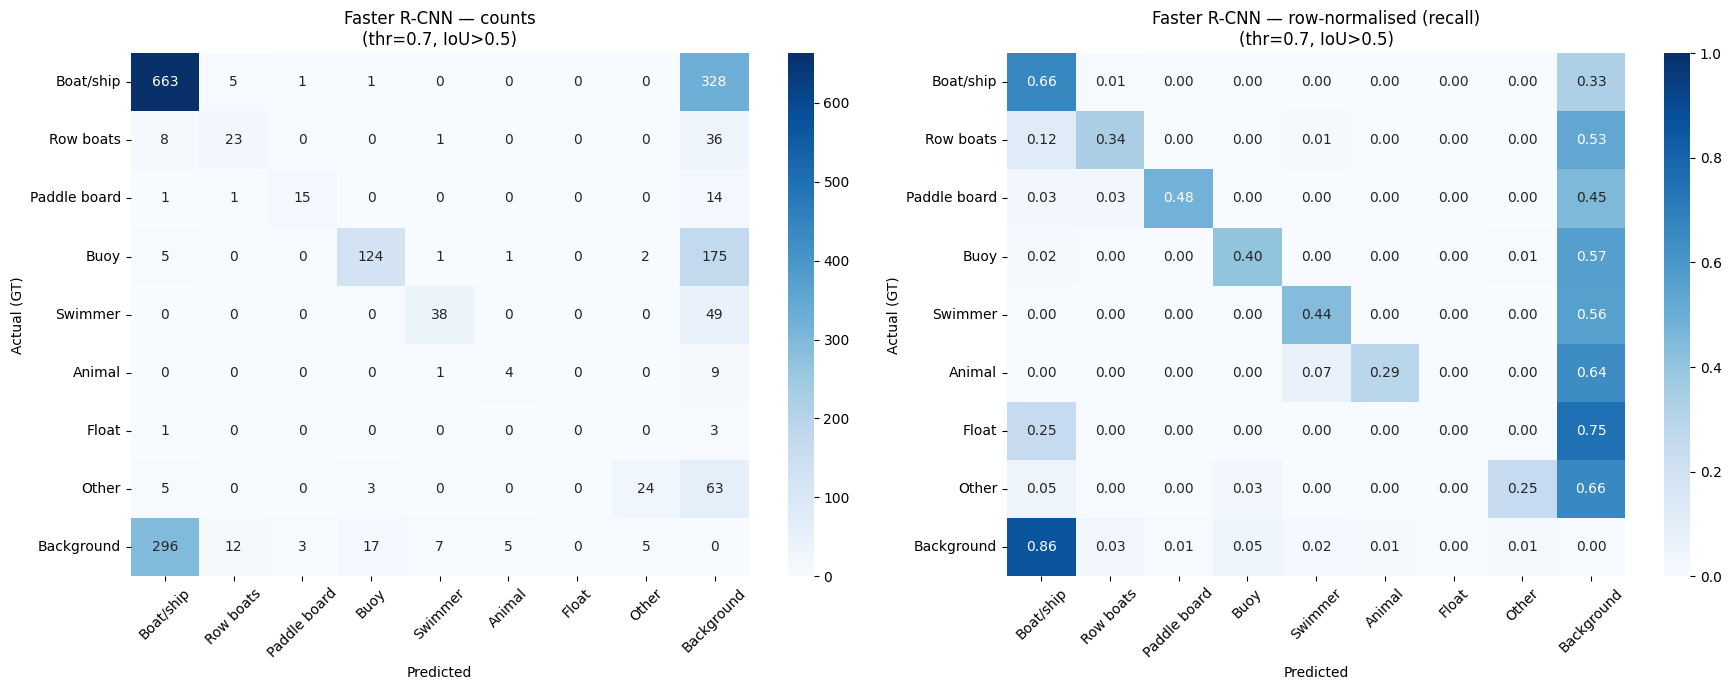

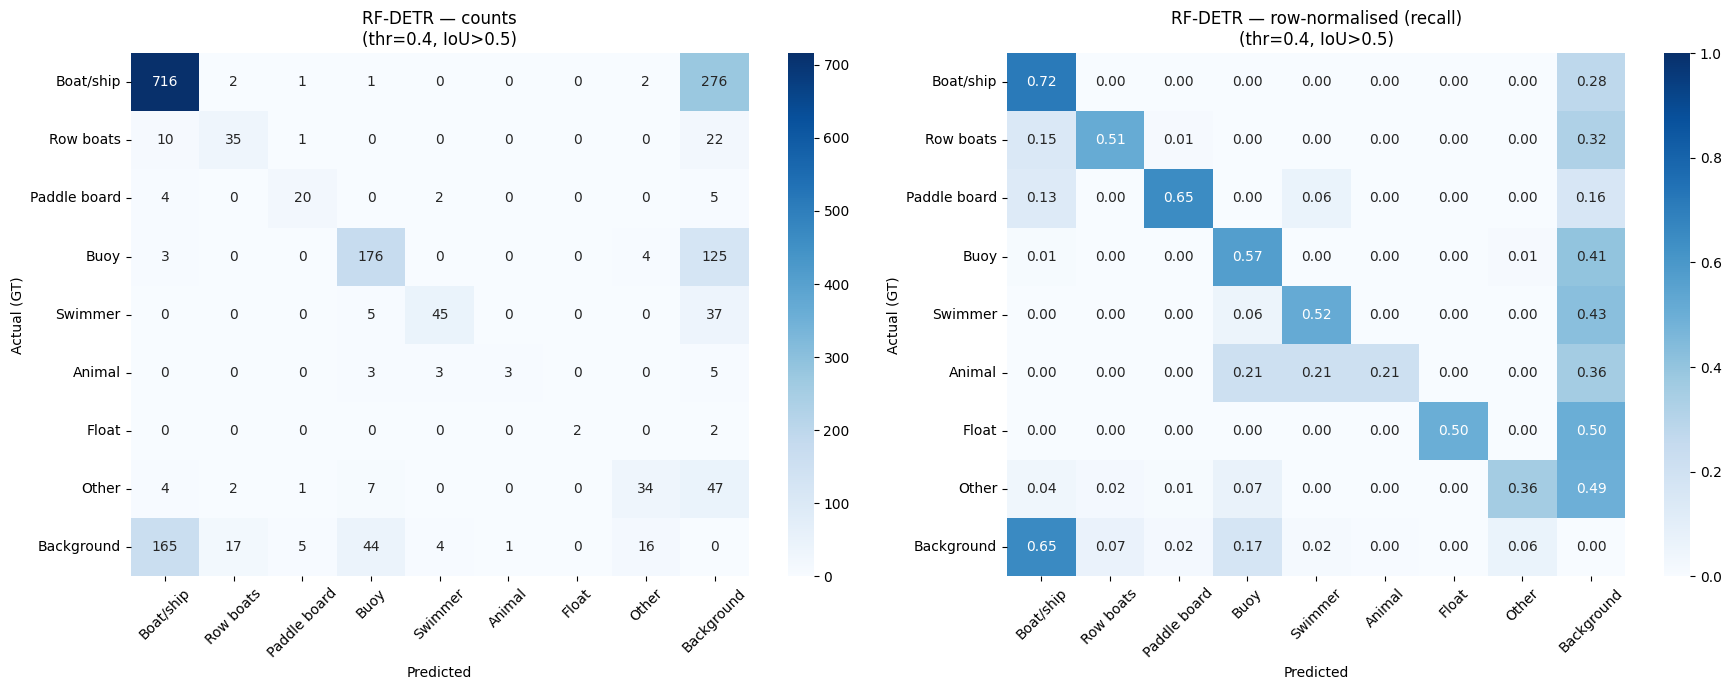

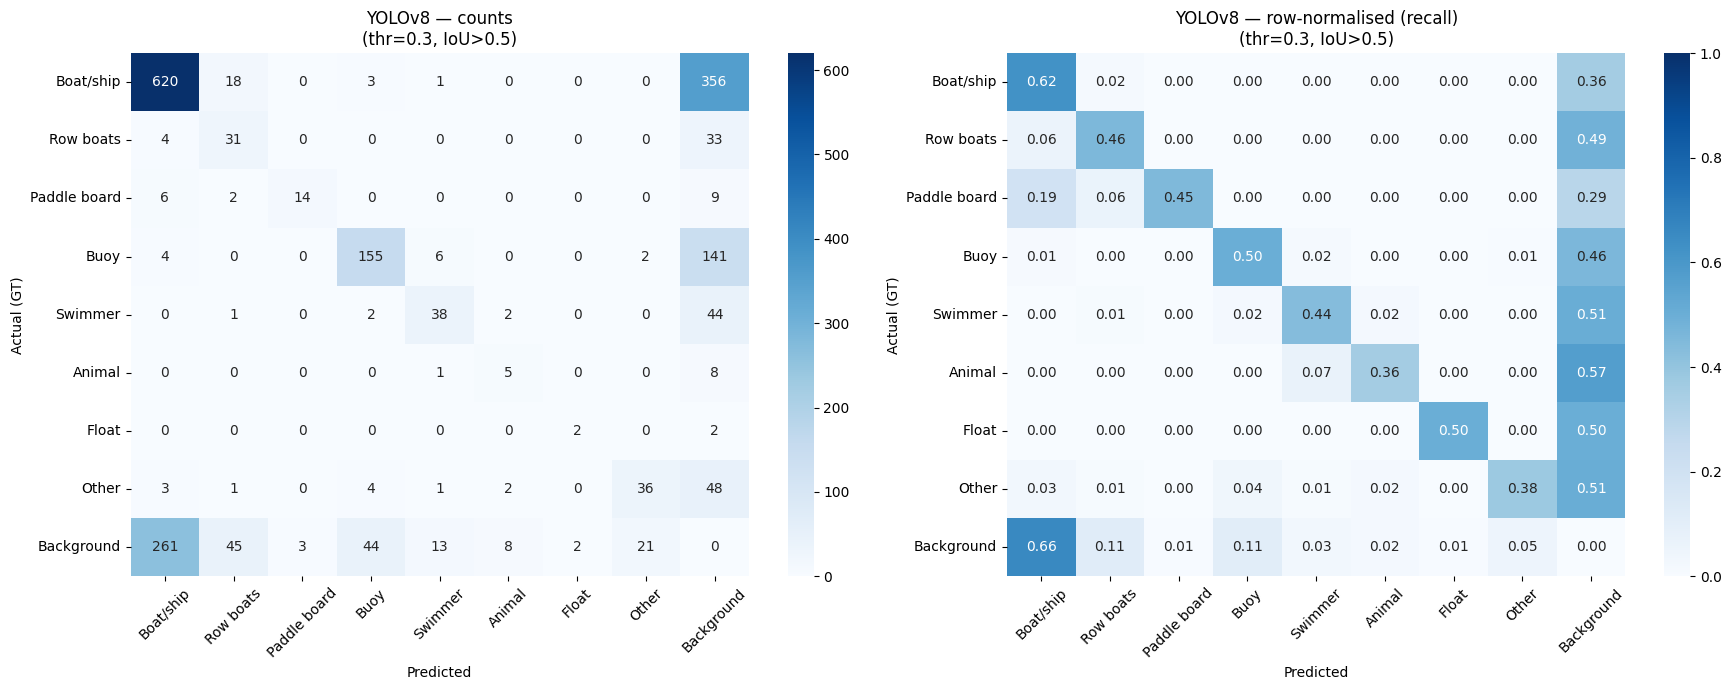

In [19]:
LABELS_BG = CLASS_NAMES + ["Background"]


def row_normalise(cm):
    """Row-normalise a confusion matrix (each GT row sums to 1)."""
    cm_norm  = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return cm_norm / row_sums


def plot_confusion(cfg):
    """Counts + row-normalised confusion matrices -> save_dir/confusion_matrix.png."""
    cm = EVAL[cfg["key"]]["cm"]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS_BG, yticklabels=LABELS_BG, ax=axes[0])
    axes[0].set_title(f"{cfg['label']} — counts\n(thr={cfg['threshold']}, IoU>{IOU_THRESH})")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual (GT)")
    axes[0].tick_params(axis="x", rotation=45)

    sns.heatmap(row_normalise(cm), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=LABELS_BG, yticklabels=LABELS_BG, ax=axes[1])
    axes[1].set_title(f"{cfg['label']} — row-normalised (recall)\n(thr={cfg['threshold']}, IoU>{IOU_THRESH})")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual (GT)")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    cfg["save_dir"].mkdir(parents=True, exist_ok=True)
    fig.savefig(cfg["save_dir"] / "confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()


for cfg in MODELS:
    plot_confusion(cfg)

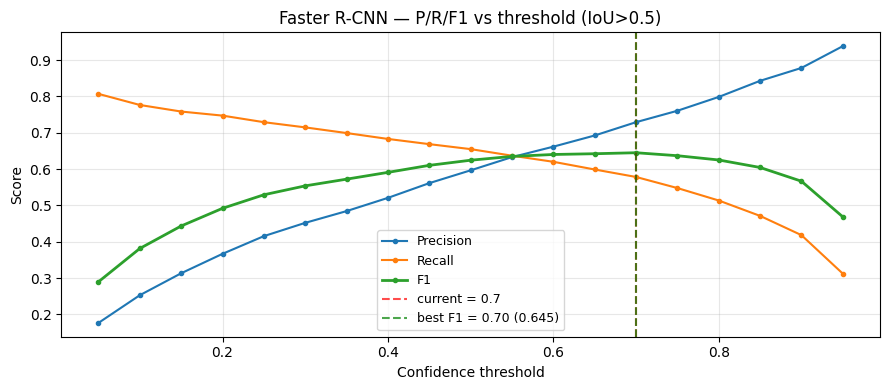

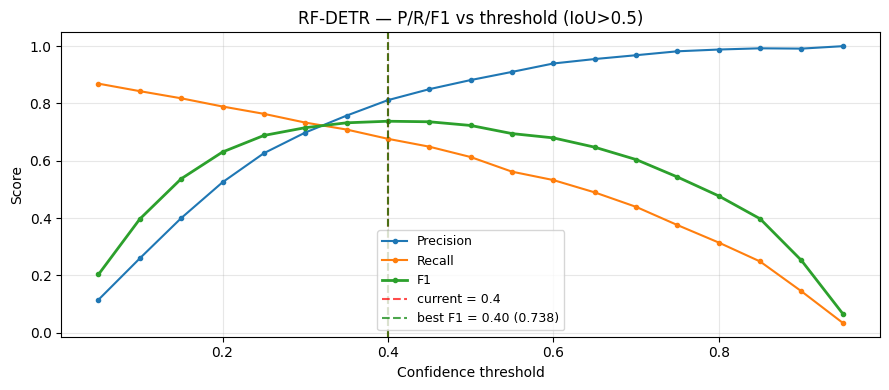

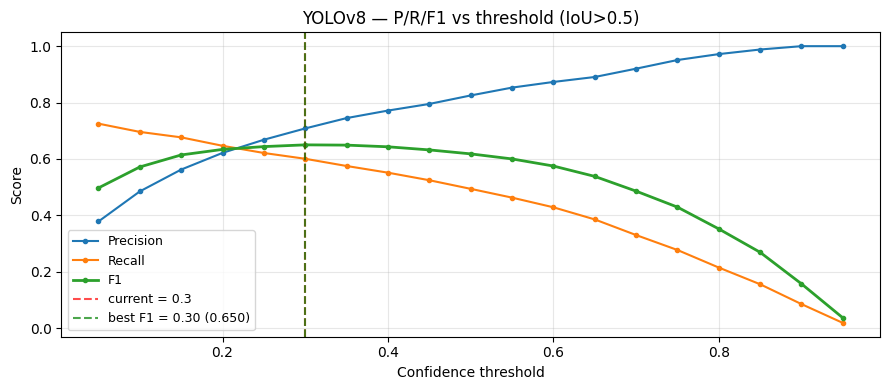

In [20]:
def plot_threshold_sweep(cfg):
    """Precision / Recall / F1 vs confidence threshold -> save_dir/threshold_sweep.png."""
    raw = EVAL[cfg["key"]]["raw_preds"]
    thresholds = np.arange(0.05, 0.96, 0.05)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        by_img = {}
        for p in raw:
            if p["score"] >= t:
                by_img.setdefault(p["image_id"], []).append(p)
        tp_t = fp_t = fn_t = 0
        for i, img_id in enumerate(IMG_ID_ORDER):
            ps = by_img.get(img_id, [])
            if ps:
                xyxy   = np.array([[p["bbox"][0], p["bbox"][1],
                                    p["bbox"][0] + p["bbox"][2],
                                    p["bbox"][1] + p["bbox"][3]] for p in ps], dtype=float)
                cids   = np.array([p["category_id"] for p in ps], dtype=int)
                scores = np.array([p["score"]       for p in ps], dtype=float)
                pred_d = sv.Detections(xyxy=xyxy, class_id=cids, confidence=scores)
            else:
                pred_d = sv.Detections(xyxy=np.empty((0, 4)), class_id=np.array([], dtype=int),
                                       confidence=np.array([], dtype=float))
            matched, fn_list, fp_list = match_detections(pred_d, all_gt_dets[i], IOU_THRESH)
            tp_t += len(matched); fp_t += len(fp_list); fn_t += len(fn_list)
        prec = tp_t / (tp_t + fp_t) if tp_t + fp_t > 0 else 0.0
        rec  = tp_t / (tp_t + fn_t) if tp_t + fn_t > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0
        precisions.append(prec); recalls.append(rec); f1s.append(f1)

    best_t = thresholds[int(np.argmax(f1s))]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(thresholds, precisions, marker="o", ms=3, label="Precision")
    ax.plot(thresholds, recalls,    marker="o", ms=3, label="Recall")
    ax.plot(thresholds, f1s,        marker="o", ms=3, label="F1", linewidth=2)
    ax.axvline(cfg["threshold"], color="red",   linestyle="--", alpha=0.7, label=f"current = {cfg['threshold']}")
    ax.axvline(best_t,           color="green", linestyle="--", alpha=0.7, label=f"best F1 = {best_t:.2f} ({max(f1s):.3f})")
    ax.set_xlabel("Confidence threshold"); ax.set_ylabel("Score")
    ax.set_title(f"{cfg['label']} — P/R/F1 vs threshold (IoU>{IOU_THRESH})")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(cfg["save_dir"] / "threshold_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()


for cfg in MODELS:
    plot_threshold_sweep(cfg)

[Faster R-CNN] smallest TP box: area=35.0 px² (w=7.0, h=5.0)  class=Buoy  img=mastr_0316_00009.jpg


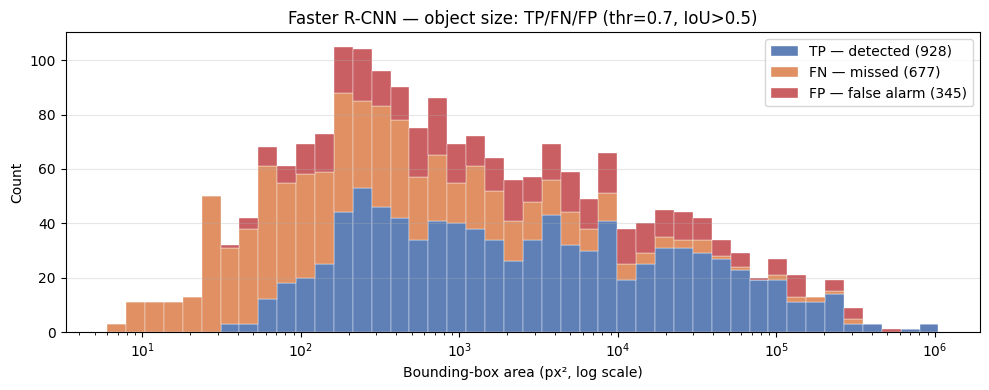

[RF-DETR] smallest TP box: area=20.0 px² (w=5.0, h=4.0)  class=Boat/ship  img=yt018_15_00020.jpg


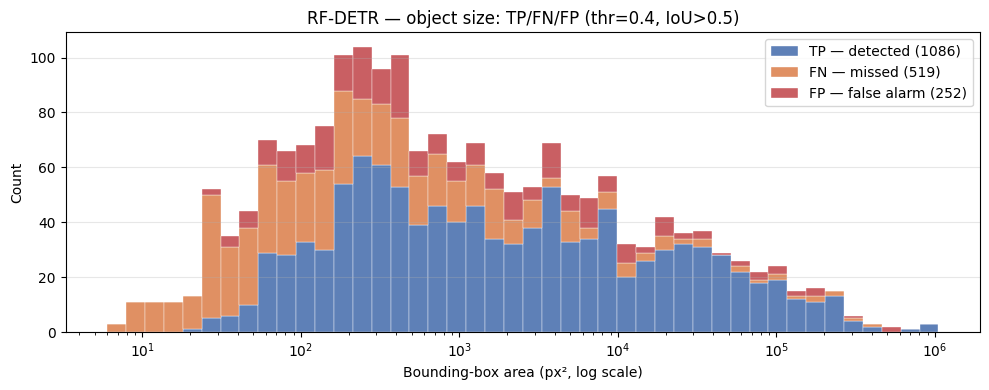

[YOLOv8] smallest TP box: area=24.0 px² (w=4.0, h=6.0)  class=Buoy  img=yt018_07_00031.jpg


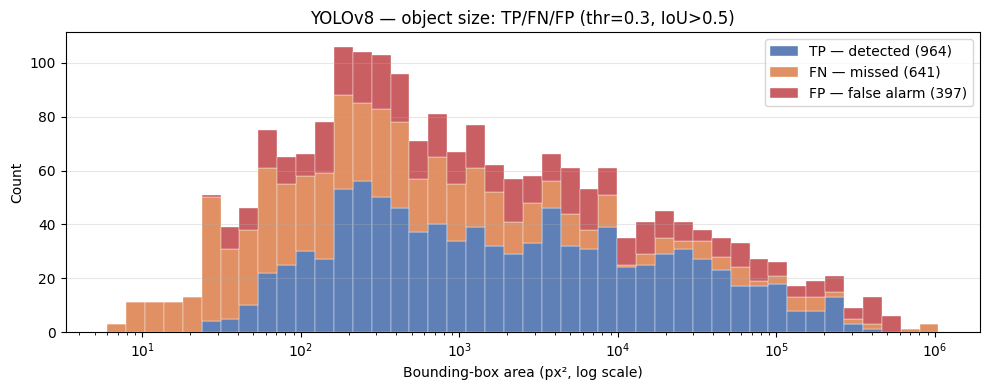

In [21]:
def _box_area(b):
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])


def plot_size_distribution(cfg):
    """Stacked TP/FN/FP histogram over box area.

    Saved to save_dir/size_distribution.png AND, for the write-up, a per-model
    copy to ../report/images/size_distribution_<key>.png.
    """
    ev = EVAL[cfg["key"]]
    tp_areas = np.array([_box_area(r["gt_box"])   for r in ev["tp_records"]])
    fn_areas = np.array([_box_area(r["gt_box"])   for r in ev["fn_records"]])
    fp_areas = np.array([_box_area(r["pred_box"]) for r in ev["fp_records"]])

    all_areas = np.concatenate([tp_areas, fn_areas, fp_areas])
    if len(all_areas) == 0:
        print(f"[{cfg['label']}] no boxes to plot"); return

    # Smallest correctly-detected (TP) object — useful for the report.
    if len(tp_areas) > 0:
        i_min = int(np.argmin(tp_areas))
        r_min = ev["tp_records"][i_min]
        x1, y1, x2, y2 = r_min["gt_box"]
        print(f"[{cfg['label']}] smallest TP box: area={tp_areas[i_min]:.1f} px² "
              f"(w={x2-x1:.1f}, h={y2-y1:.1f})  class={CLASS_NAMES[r_min['gt_cls']]}  "
              f"img={img_meta[r_min['img_id']]['file_name']}")

    bins = np.logspace(np.log10(max(all_areas.min(), 1)), np.log10(all_areas.max()), 45)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist([tp_areas, fn_areas, fp_areas], bins=bins, stacked=True,
            label=[f"TP — detected ({len(tp_areas)})",
                   f"FN — missed ({len(fn_areas)})",
                   f"FP — false alarm ({len(fp_areas)})"],
            color=["#4C72B0", "#DD8452", "#C44E52"], alpha=0.9, edgecolor="white", linewidth=0.3)
    ax.set_xscale("log")
    ax.set_xlabel("Bounding-box area (px², log scale)"); ax.set_ylabel("Count")
    ax.set_title(f"{cfg['label']} — object size: TP/FN/FP (thr={cfg['threshold']}, IoU>{IOU_THRESH})")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    # Per-model copy in runs/ (alongside the other diagnostics)
    cfg["save_dir"].mkdir(parents=True, exist_ok=True)
    fig.savefig(cfg["save_dir"] / "size_distribution.png", dpi=150, bbox_inches="tight")
    # Per-model copy in the report images folder for the write-up
    fig.savefig(REPORT_IMG_DIR / f"size_distribution_{cfg['key']}.png", dpi=150, bbox_inches="tight")
    plt.show()


for cfg in MODELS:
    plot_size_distribution(cfg)

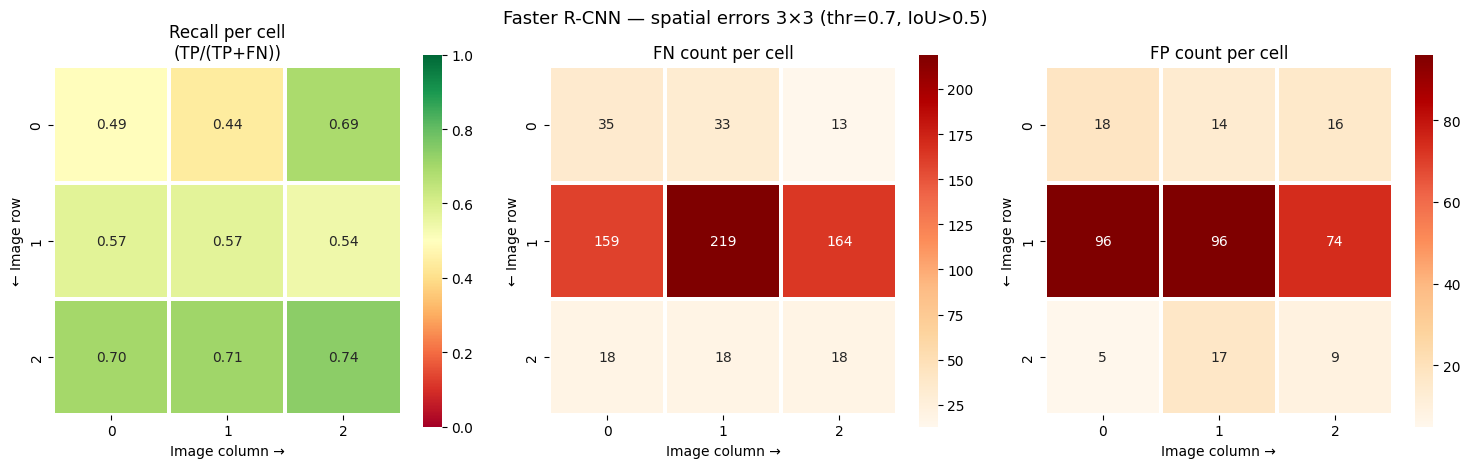

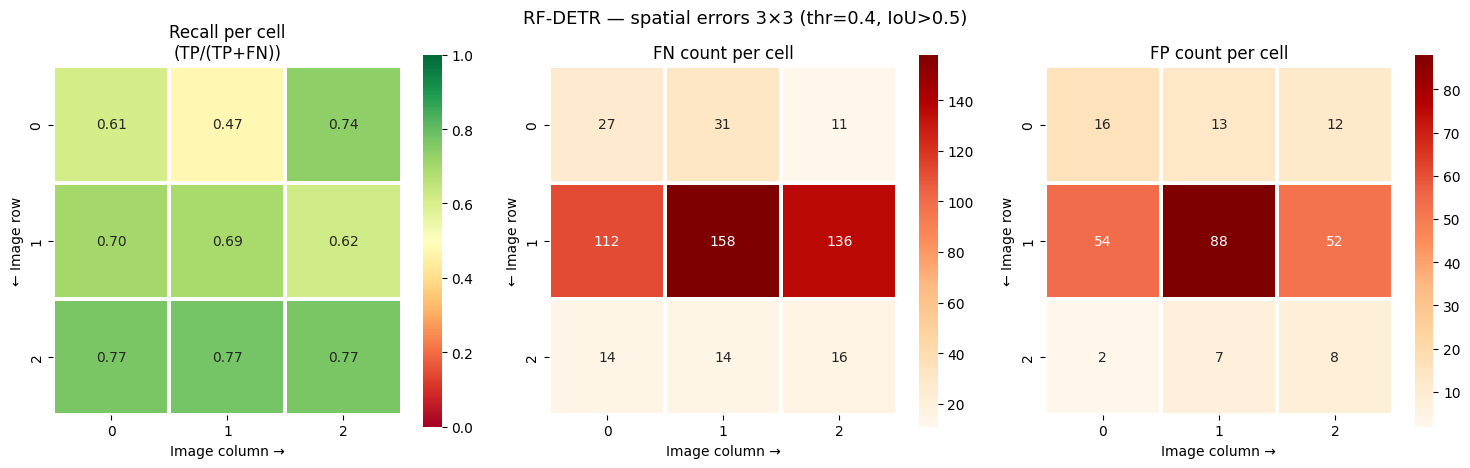

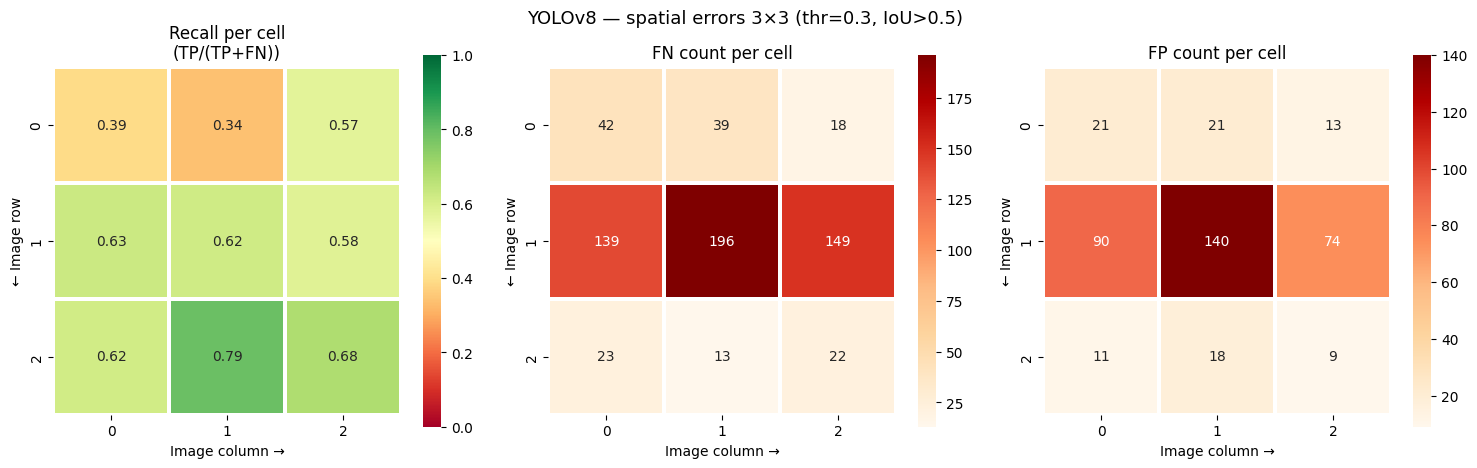

In [22]:
GRID = 3  # NxN spatial grid


def plot_location_grid(cfg):
    """Recall / FN / FP heatmaps over a 3x3 image grid -> save_dir/location_grid.png."""
    ev = EVAL[cfg["key"]]

    def cell(cx, cy, n=GRID):
        return min(int(cy * n), n - 1), min(int(cx * n), n - 1)

    tp_loc = np.zeros((GRID, GRID), dtype=int)
    fn_loc = np.zeros((GRID, GRID), dtype=int)
    fp_loc = np.zeros((GRID, GRID), dtype=int)

    for r in ev["tp_records"]:
        m = img_meta[r["img_id"]]; b = r["gt_box"]
        row, col = cell(((b[0] + b[2]) / 2) / m["width"], ((b[1] + b[3]) / 2) / m["height"])
        tp_loc[row, col] += 1
    for r in ev["fn_records"]:
        m = img_meta[r["img_id"]]; b = r["gt_box"]
        row, col = cell(((b[0] + b[2]) / 2) / m["width"], ((b[1] + b[3]) / 2) / m["height"])
        fn_loc[row, col] += 1
    for r in ev["fp_records"]:
        m = img_meta[r["img_id"]]; b = r["pred_box"]
        row, col = cell(((b[0] + b[2]) / 2) / m["width"], ((b[1] + b[3]) / 2) / m["height"])
        fp_loc[row, col] += 1

    denom = tp_loc + fn_loc
    recall_loc = np.where(denom > 0, tp_loc / denom, np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    kw = dict(linewidths=1.5, square=True)
    sns.heatmap(recall_loc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                mask=np.isnan(recall_loc), ax=axes[0], **kw)
    axes[0].set_title("Recall per cell\n(TP/(TP+FN))")
    sns.heatmap(fn_loc, annot=True, fmt="d", cmap="OrRd", ax=axes[1], **kw)
    axes[1].set_title("FN count per cell")
    sns.heatmap(fp_loc, annot=True, fmt="d", cmap="OrRd", ax=axes[2], **kw)
    axes[2].set_title("FP count per cell")
    for ax in axes:
        ax.set_xlabel("Image column →"); ax.set_ylabel("← Image row")
    plt.suptitle(f"{cfg['label']} — spatial errors {GRID}×{GRID} (thr={cfg['threshold']}, IoU>{IOU_THRESH})",
                 fontsize=13)
    plt.tight_layout()
    fig.savefig(cfg["save_dir"] / "location_grid.png", dpi=150, bbox_inches="tight")
    plt.show()


for cfg in MODELS:
    plot_location_grid(cfg)

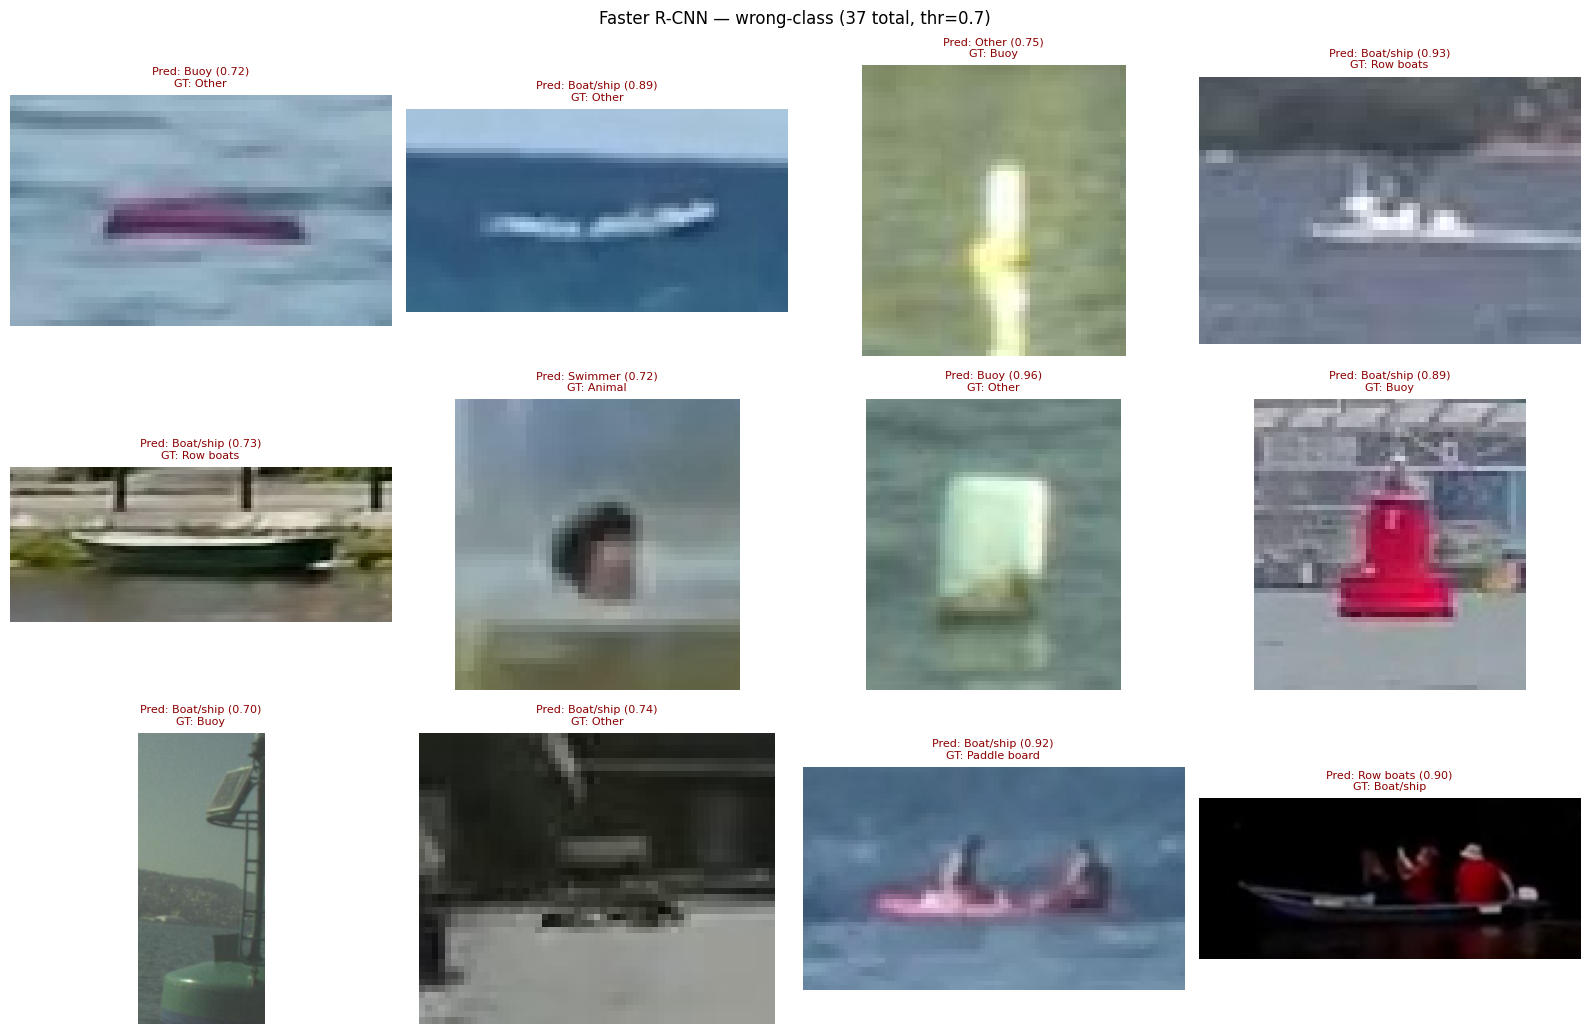

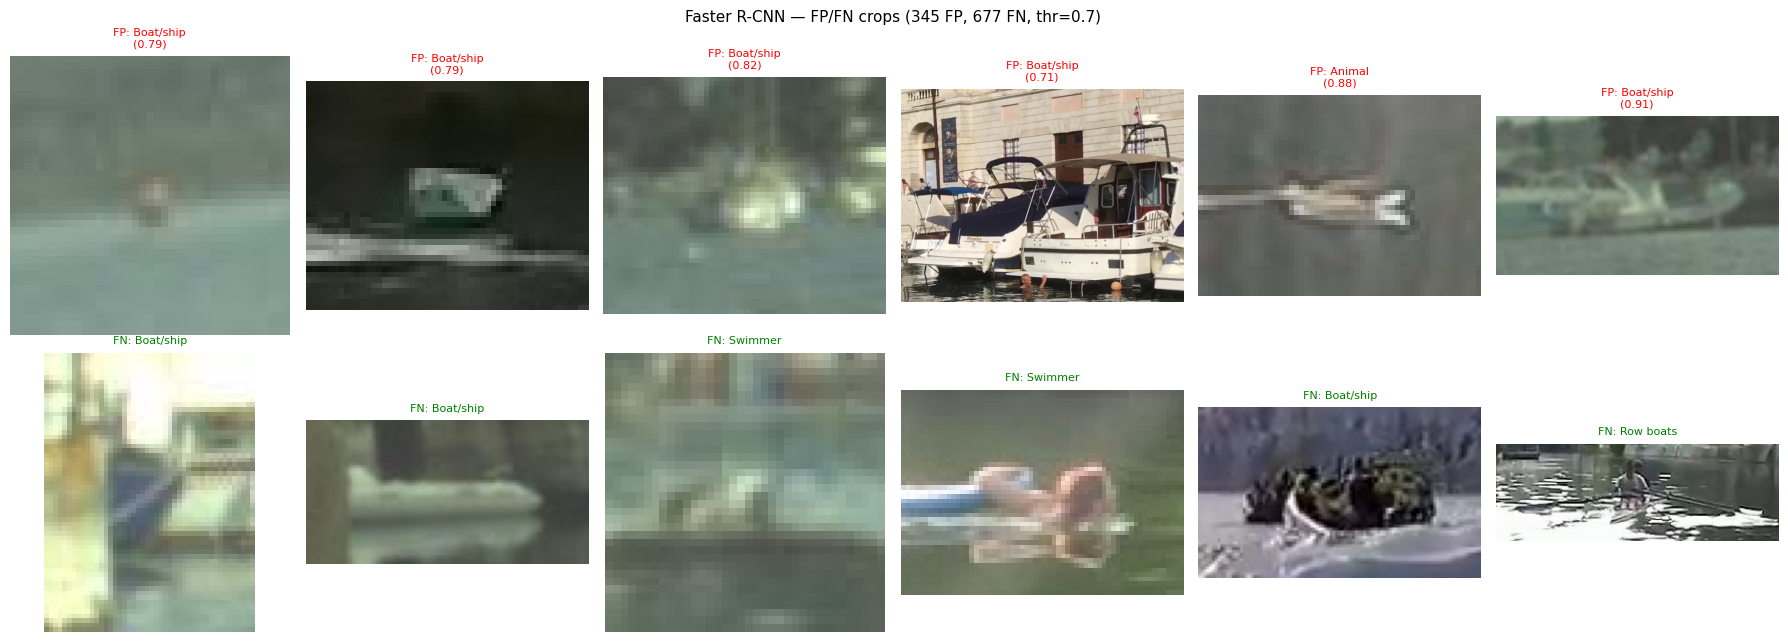

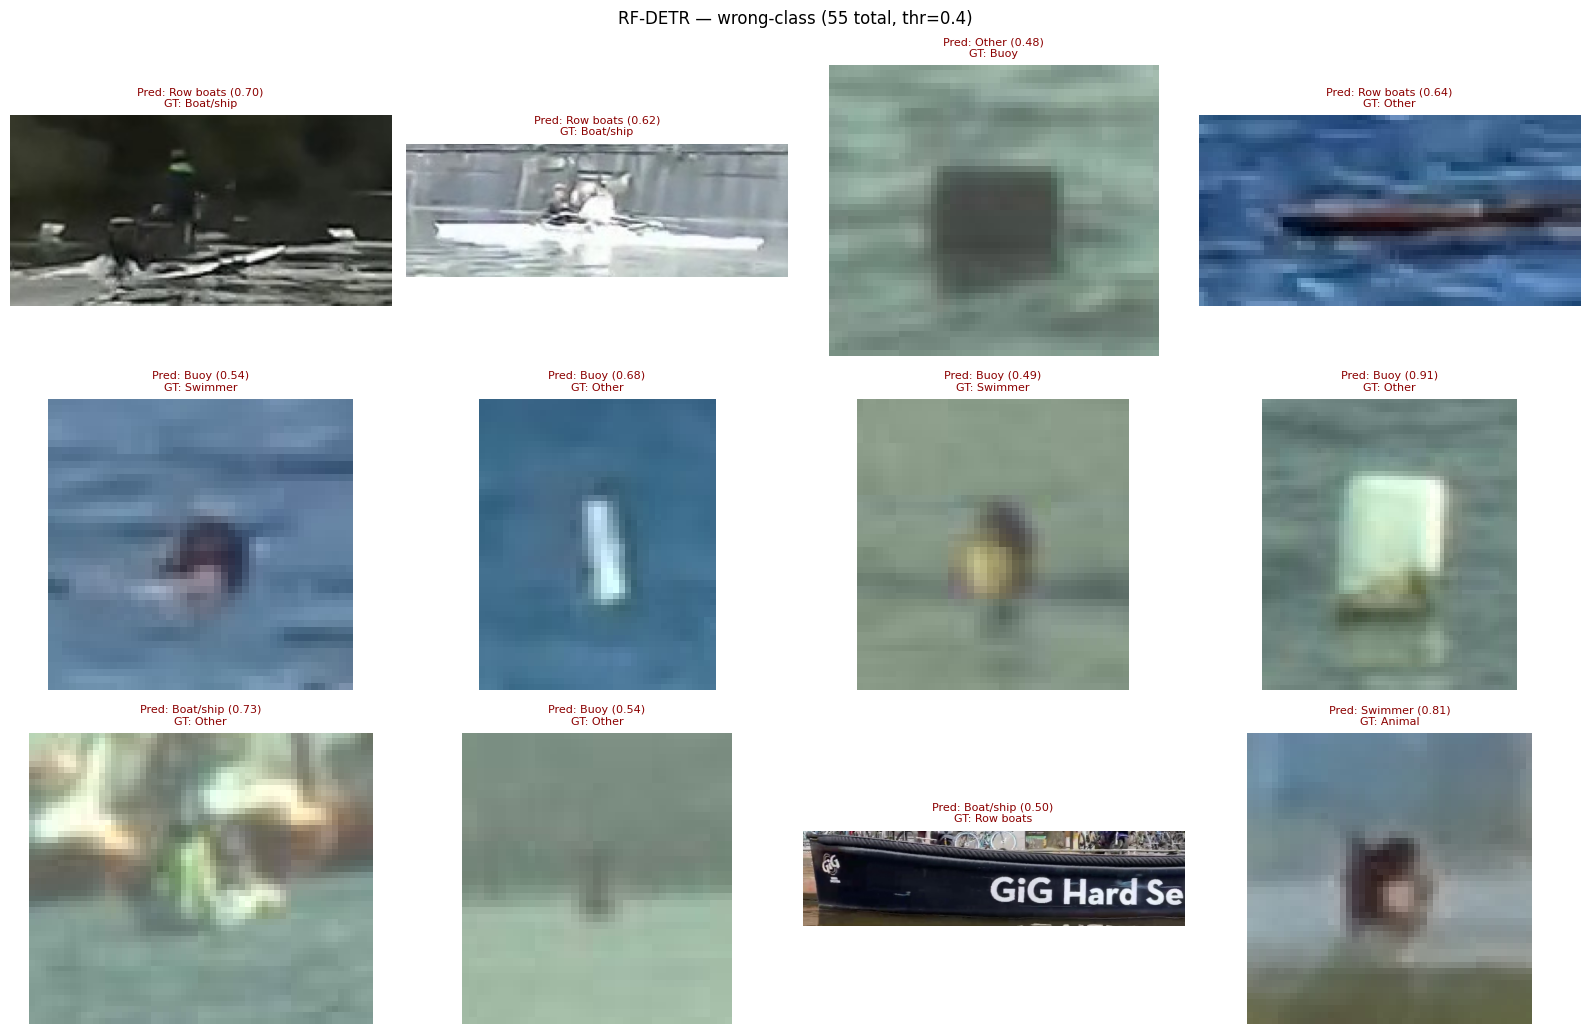

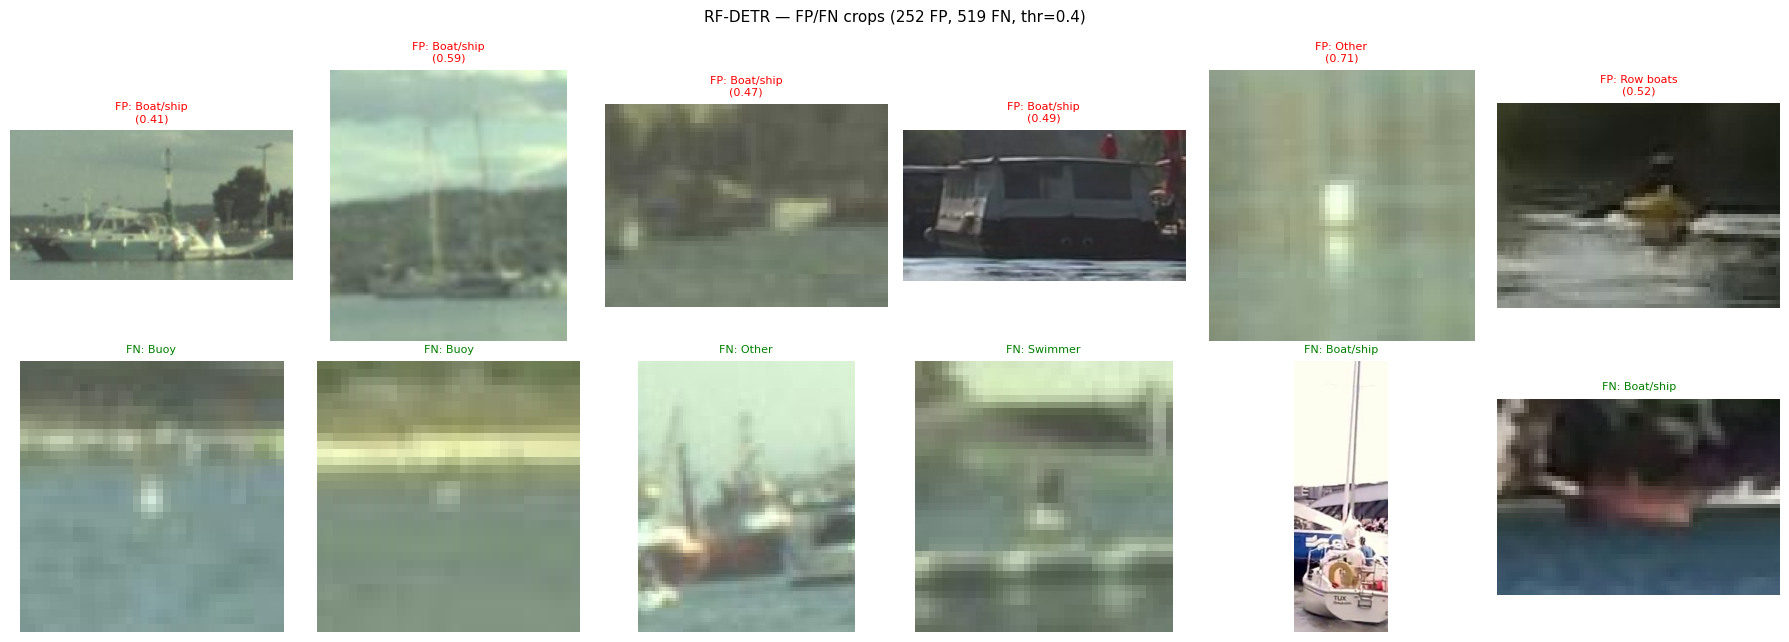

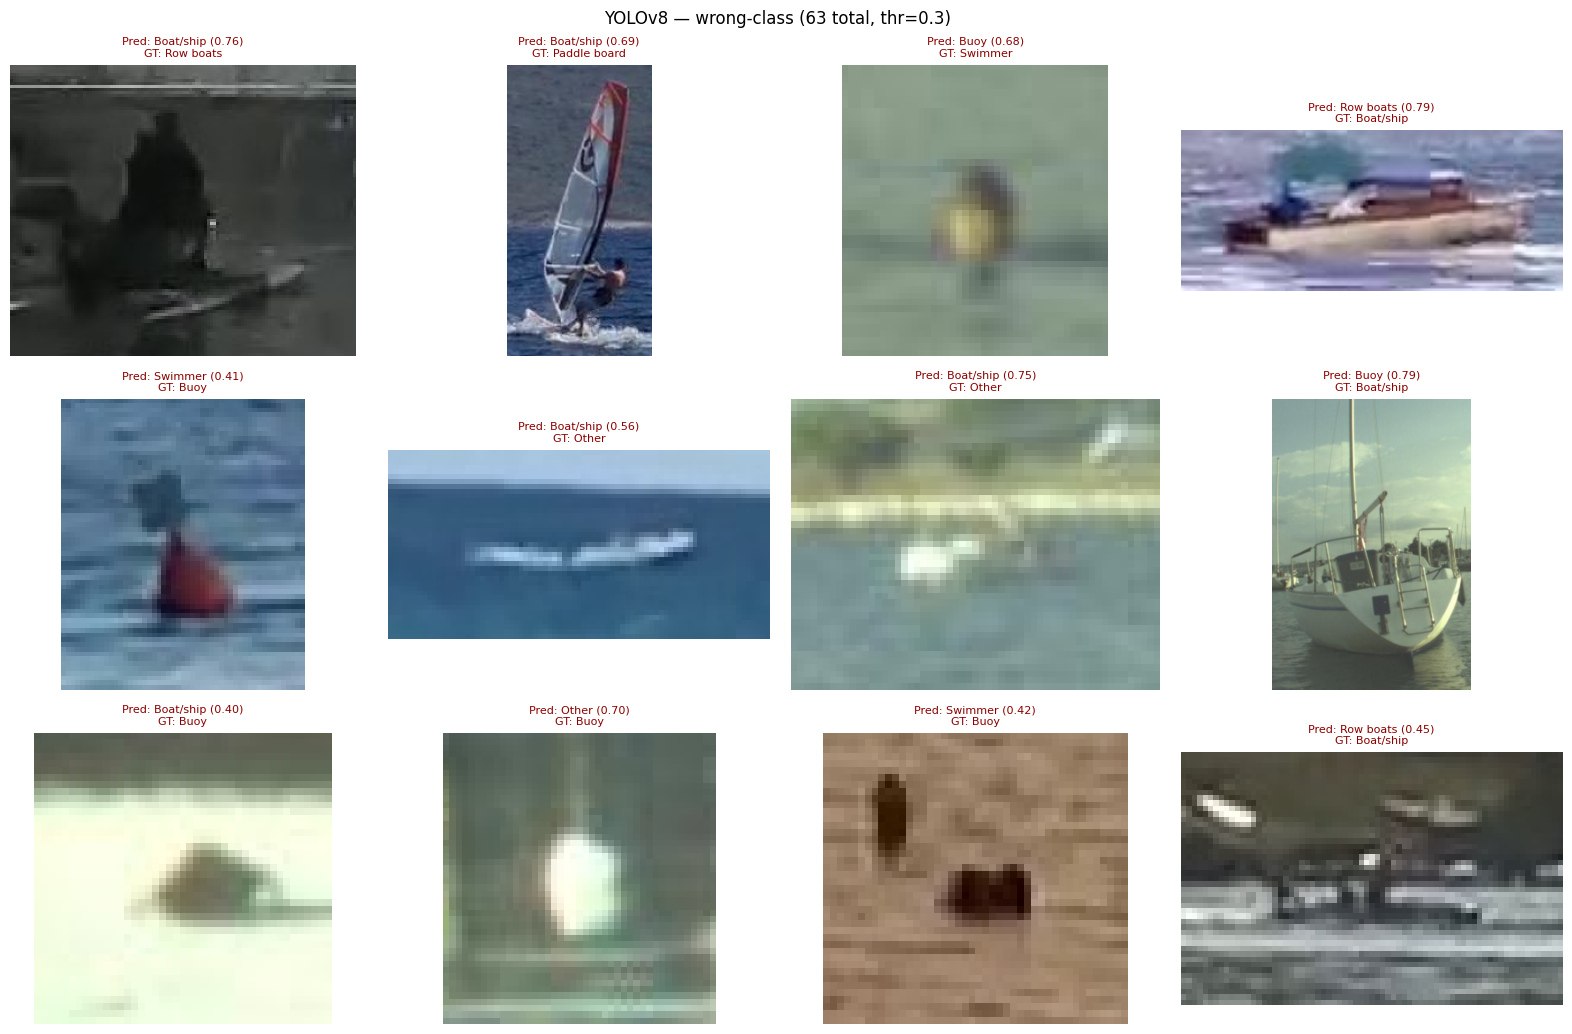

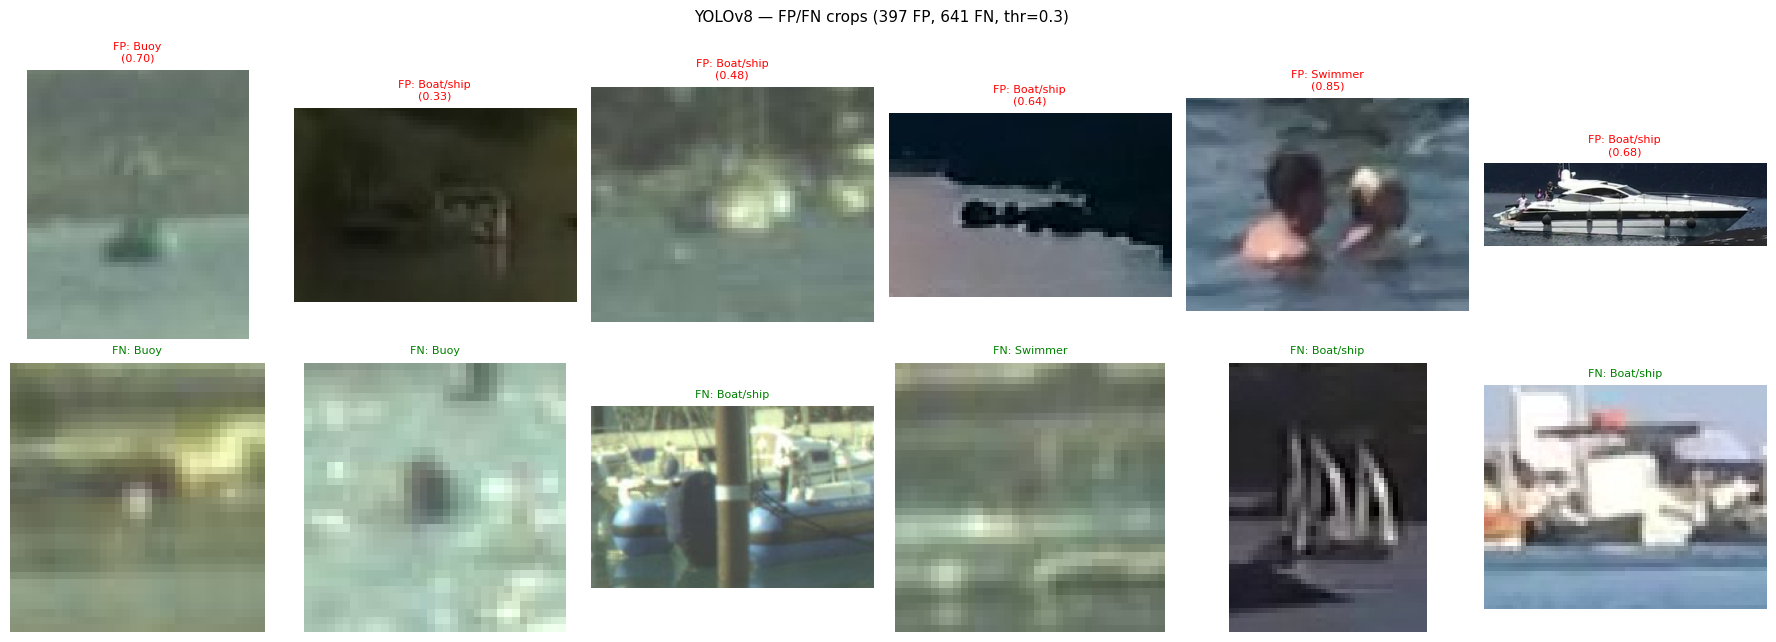

In [23]:
def _crop(arr, box, pad=15):
    h, w = arr.shape[:2]
    x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
    return arr[max(0, y1 - pad):min(h, y2 + pad), max(0, x1 - pad):min(w, x2 + pad)]


def plot_wrong_class(cfg):
    """Sample of right-location / wrong-category crops -> save_dir/wrong_class.png."""
    examples = EVAL[cfg["key"]]["wrong_class_examples"]
    n_show = min(12, len(examples))
    if n_show == 0:
        print(f"[{cfg['label']}] no wrong-class predictions at thr={cfg['threshold']}"); return
    random.seed(4)
    samples = random.sample(examples, n_show)
    cols = 4; rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = np.array(axes).reshape(-1)
    for ax, (img_path, pb, pc, ps, gb, gc) in zip(axes, samples):
        arr = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(_crop(arr, pb))
        ax.set_title(f"Pred: {cls_name(pc)} ({ps:.2f})\nGT: {cls_name(gc)}", fontsize=8, color="darkred")
        ax.axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    plt.suptitle(f"{cfg['label']} — wrong-class ({len(examples)} total, thr={cfg['threshold']})", fontsize=12)
    plt.tight_layout()
    fig.savefig(cfg["save_dir"] / "wrong_class.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_fp_fn_crops(cfg):
    """Top row = FP crops, bottom row = FN crops -> save_dir/fp_fn_crops.png."""
    ev = EVAL[cfg["key"]]
    fp_examples = [(p, b, c, s) for p, fps in ev["fp_by_image"].items() for b, c, s in fps]
    fn_examples = [(p, b, c)    for p, fns in ev["fn_by_image"].items() for b, c    in fns]
    if not fp_examples and not fn_examples:
        print(f"[{cfg['label']}] no FP/FN to show"); return
    random.seed(4)
    n_each = 6
    fp_sample = random.sample(fp_examples, min(n_each, len(fp_examples)))
    fn_sample = random.sample(fn_examples, min(n_each, len(fn_examples)))
    n_cols = max(len(fp_sample), len(fn_sample), 1)
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6.5))
    axes = np.array(axes).reshape(2, n_cols)
    for col, (img_path, box, c, s) in enumerate(fp_sample):
        axes[0, col].imshow(_crop(np.array(Image.open(img_path).convert("RGB")), box))
        axes[0, col].set_title(f"FP: {cls_name(c)}\n({s:.2f})", fontsize=8, color="red")
    for col, (img_path, box, c) in enumerate(fn_sample):
        axes[1, col].imshow(_crop(np.array(Image.open(img_path).convert("RGB")), box))
        axes[1, col].set_title(f"FN: {cls_name(c)}", fontsize=8, color="green")
    for col in range(n_cols):
        axes[0, col].axis("off"); axes[1, col].axis("off")
    plt.suptitle(f"{cfg['label']} — FP/FN crops ({len(fp_examples)} FP, {len(fn_examples)} FN, thr={cfg['threshold']})",
                 fontsize=11)
    plt.tight_layout()
    fig.savefig(cfg["save_dir"] / "fp_fn_crops.png", dpi=150, bbox_inches="tight")
    plt.show()


for cfg in MODELS:
    plot_wrong_class(cfg)
    plot_fp_fn_crops(cfg)

## 7. Report figure — row-normalised confusion matrices (all models)

The comparison figure for the report: the three models' **row-normalised**
confusion matrices side by side (each cell = fraction of that GT class predicted
as the column class; diagonal = per-class recall). Saved to `../report/images/`.

Saved report figure -> /home/ubuntu/workspace/navigation_project/AP2026-Maritime-Navigation/report/images/confusion_matrix_rownorm_all_models.png


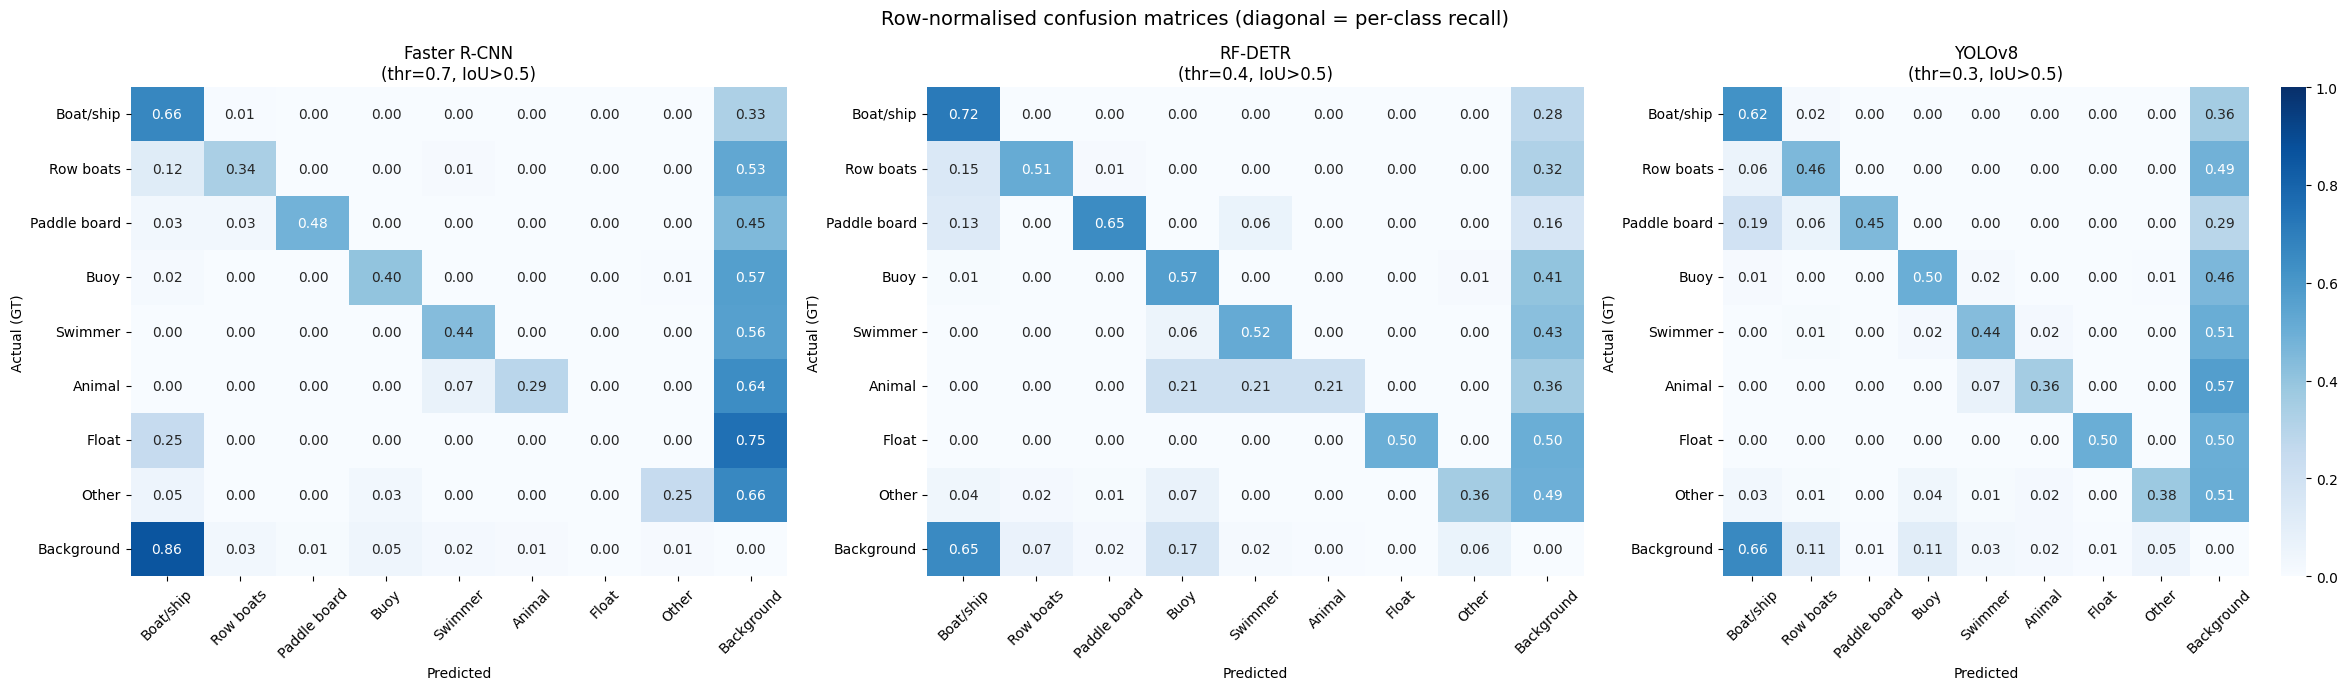

In [24]:
# Side-by-side row-normalised confusion matrices, one column per model.
fig, axes = plt.subplots(1, len(MODELS), figsize=(8 * len(MODELS), 7))
if len(MODELS) == 1:
    axes = [axes]

for ax, cfg in zip(axes, MODELS):
    cm_norm = row_normalise(EVAL[cfg["key"]]["cm"])
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=LABELS_BG, yticklabels=LABELS_BG, ax=ax,
                cbar=(ax is axes[-1]))   # single shared-looking colourbar on the right
    ax.set_title(f"{cfg['label']}\n(thr={cfg['threshold']}, IoU>{IOU_THRESH})", fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (GT)")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Row-normalised confusion matrices (diagonal = per-class recall)", fontsize=14)
plt.tight_layout()
out_path = REPORT_IMG_DIR / "confusion_matrix_rownorm_all_models.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved report figure -> {out_path}")
plt.show()